# AI MarketLens
## AI-Powered Global Data Science & AI Job Market Intelligence Platform

**Academic Internship Project — Master Notebook**

---

## 1. Executive Summary

This notebook presents a complete end-to-end analysis of a global AI and Data Science job market dataset containing **50,000 job postings** across 6 countries, 6 job roles, and 7 years (2020–2026). The analysis covers exploratory data analysis, salary modelling, skills intelligence, country-level market trends, statistical hypothesis testing, and unsupervised clustering.

**Key findings previewed:**
- Experience level is the single strongest determinant of salary (Entry ~\$67k, Mid ~\$107k, Senior ~\$157k).
- All other categorical dimensions (country, industry, role, company type/size, remote type) show near-uniform distributions — a signature of synthetic data generation.
- The dataset covers 2020–2024 as historical data and 2025–2026 as projected/synthetic forward data.
- A direct job-level skills join is unavailable (4.1% key overlap); skills are analysed independently.

> **Important:** This dataset is synthetically generated. ML models trained here serve as educational demonstrations and do not generalise to real-world hiring markets.

## 2. Business Problem

Organisations and job seekers alike face significant uncertainty in the AI/Data Science job market:
- Which roles and skills are in highest demand?
- How do salaries vary by experience, geography, and role?
- How is remote work adoption evolving across countries?
- Which countries lead in AI job market growth?

This platform aims to provide data-driven answers to these questions through interactive analytics and predictive modelling.

## 3. Objectives

1. Perform thorough exploratory data analysis of the AI job market dataset.
2. Engineer meaningful analytical features from raw columns.
3. Conduct rigorous statistical analysis of salary determinants.
4. Build and compare salary regression models.
5. Apply unsupervised clustering to discover job profile segments.
6. Extract actionable insights and business recommendations.
7. Produce clean, dashboard-ready processed datasets.

## 4. Dataset Overview

| File | Rows | Columns | Role |
|---|---|---|---|
| ai_jobs.csv | 50,000 | 14 | Main fact table |
| skills_demand.csv | 224,605 | 4 | Job-skill bridge (key mismatch — independent analysis) |
| country_ai_trends.csv | 42 | 6 | Country-level aggregate dimension |
| job_title_mapping.csv | 6 | 3 | Job title lookup dimension |
| data_dictionary.csv | 13 | 3 | Metadata |

**Known data quality issues documented in audit:**
- `employment_type`: zero variance (all Full-time) — excluded from analysis.
- `min_experience_years`: perfectly encodes `experience_level` — treated as redundant.
- `city == 'Remote'`: perfectly predicts `remote_type == 'Remote'` — leakage pair.
- `skills_demand.job_id` → `ai_jobs.job_id`: only 4.1% match — **no direct join performed**.
- `posted_year` 2025–2026: projected/synthetic forward data — labelled separately.

## 5. Data Dictionary

| Column | Source | Type | Description |
|---|---|---|---|
| job_id | ai_jobs | str | Unique 12-char job identifier (PK) |
| job_title | ai_jobs | str | Job role (6 values) |
| company_type | ai_jobs | str | Startup / MNC / Research Lab |
| industry | ai_jobs | str | Tech / Healthcare / Retail / Finance / Education |
| country | ai_jobs | str | 6 countries |
| city | ai_jobs | str | City or 'Remote' |
| remote_type | ai_jobs | str | Remote / Hybrid / Onsite |
| experience_level | ai_jobs | str | Entry / Mid / Senior |
| min_experience_years | ai_jobs | int | 0/2/5 — redundant with experience_level |
| salary_min_usd | ai_jobs | int | Min annual salary (USD) |
| salary_max_usd | ai_jobs | int | Max annual salary (USD) |
| employment_type | ai_jobs | str | All Full-time — zero variance, excluded |
| posted_year | ai_jobs | int | 2020–2026 |
| company_size | ai_jobs | str | Small / Medium / Large |
| salary_mid | engineered | float | (salary_min + salary_max) / 2 |
| salary_range | engineered | float | salary_max - salary_min |
| role_category | job_title_mapping | str | Analytics / Engineering |
| period_type | engineered | str | Historical (2020-2024) / Projected (2025-2026) |
| skill | skills_demand | str | Required technical skill (11 values) |
| skill_category | skills_demand | str | Programming / ML / Cloud |
| skill_level | skills_demand | str | Basic / Intermediate / Advanced |
| total_ai_jobs | country_ai_trends | int | Market-wide AI job count |
| avg_salary_usd | country_ai_trends | int | Country-year average salary |
| remote_percentage | country_ai_trends | int | % remote AI jobs |
| top_skill | country_ai_trends | str | Most demanded skill that country-year |

---
## 6. Setup & Imports

In [1]:
import sys
import warnings
from pathlib import Path

# Ensure the project root is on the path so src/ modules are importable
PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from scipy import stats
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.cluster import KMeans
from sklearn.inspection import permutation_importance
from sklearn.metrics import silhouette_score, davies_bouldin_score

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# Plot style
sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
    'axes.titlesize': 13,
})

HIST_COLOR = '#3b82d4'
PROJ_COLOR = '#f59e0b'
NEUTRAL    = '#57606a'

print('All imports successful.')
print(f'Project root: {PROJECT_ROOT}')

All imports successful.
Project root: C:\Users\Ritu\OneDrive\Desktop\AI-Data-Science-Job-Market-Analytics


---
## 7. Data Loading

In [2]:
from src.data_loader import load_all, validate_raw_files

print('=== Raw File Validation ===')
validation = validate_raw_files(verbose=True)

raw = load_all()
ai_jobs           = raw['ai_jobs']
skills_demand     = raw['skills_demand']
country_ai_trends = raw['country_ai_trends']
job_title_mapping = raw['job_title_mapping']
data_dictionary   = raw['data_dictionary']

print(f'\nLoaded all 5 raw files successfully.')

=== Raw File Validation ===


  OK ai_jobs                shape=(50000, 14)  missing=0  dupes=0


  OK skills_demand          shape=(224605, 4)  missing=0  dupes=0
  OK country_ai_trends      shape=(42, 6)  missing=0  dupes=0
  OK job_title_mapping      shape=(6, 3)  missing=0  dupes=0
  OK data_dictionary        shape=(13, 3)  missing=0  dupes=0



Loaded all 5 raw files successfully.


---
## 8. Data Quality Validation

In [3]:
def quality_report(df, name):
    print(f'\n--- {name} ---')
    print(f'  Shape       : {df.shape[0]:,} rows x {df.shape[1]} columns')
    print(f'  Missing     : {df.isnull().sum().sum()}')
    print(f'  Duplicates  : {df.duplicated().sum()}')
    print(f'  dtypes      : {dict(df.dtypes.value_counts())}')

for name, df in raw.items():
    quality_report(df, name)


--- ai_jobs ---
  Shape       : 50,000 rows x 14 columns
  Missing     : 0
  Duplicates  : 0
  dtypes      : {<StringDtype(na_value=nan)>: np.int64(10), dtype('int64'): np.int64(4)}

--- skills_demand ---
  Shape       : 224,605 rows x 4 columns
  Missing     : 0
  Duplicates  : 0
  dtypes      : {<StringDtype(na_value=nan)>: np.int64(4)}

--- country_ai_trends ---
  Shape       : 42 rows x 6 columns
  Missing     : 0
  Duplicates  : 0
  dtypes      : {dtype('int64'): np.int64(4), <StringDtype(na_value=nan)>: np.int64(2)}

--- job_title_mapping ---
  Shape       : 6 rows x 3 columns
  Missing     : 0
  Duplicates  : 0
  dtypes      : {<StringDtype(na_value=nan)>: np.int64(3)}

--- data_dictionary ---
  Shape       : 13 rows x 3 columns
  Missing     : 0
  Duplicates  : 0
  dtypes      : {<StringDtype(na_value=nan)>: np.int64(3)}


In [4]:
# Verify known join integrity
skills_ids  = set(skills_demand['job_id'].unique())
jobs_ids    = set(ai_jobs['job_id'].unique())
overlap_pct = len(skills_ids & jobs_ids) / len(jobs_ids) * 100

jtm_match   = set(job_title_mapping['job_title']) == set(ai_jobs['job_title'].unique())
country_match = set(country_ai_trends['country']) == set(ai_jobs['country'].unique())
year_match    = set(country_ai_trends['year'])    == set(ai_jobs['posted_year'].unique())

print('Join integrity checks:')
print(f'  skills_demand.job_id -> ai_jobs.job_id  : {overlap_pct:.1f}% overlap  (KNOWN ISSUE - no direct join)')
print(f'  job_title_mapping -> ai_jobs.job_title  : {jtm_match}  (100% match)')
print(f'  country_ai_trends.country match         : {country_match}  (100% match)')
print(f'  country_ai_trends.year match            : {year_match}  (100% match)')

Join integrity checks:
  skills_demand.job_id -> ai_jobs.job_id  : 4.1% overlap  (KNOWN ISSUE - no direct join)
  job_title_mapping -> ai_jobs.job_title  : True  (100% match)
  country_ai_trends.country match         : True  (100% match)
  country_ai_trends.year match            : True  (100% match)


---
## 9. Data Cleaning & Preprocessing

In [5]:
from src.preprocessing import (
    clean_jobs, build_country_enriched,
    clean_skills, build_skill_summary, clean_country_trends
)

# Build all clean datasets
jobs_clean            = clean_jobs(ai_jobs, job_title_mapping)
jobs_enriched         = build_country_enriched(jobs_clean, country_ai_trends)
skills_clean          = clean_skills(skills_demand)
skill_summary         = build_skill_summary(skills_clean)
country_trends_clean  = clean_country_trends(country_ai_trends)

print('Cleaned dataset shapes:')
print(f'  jobs_clean           : {jobs_clean.shape}')
print(f'  jobs_enriched        : {jobs_enriched.shape}')
print(f'  skills_clean         : {skills_clean.shape}')
print(f'  skill_summary        : {skill_summary.shape}')
print(f'  country_trends_clean : {country_trends_clean.shape}')

# Verify row counts preserved
assert len(jobs_clean)   == 50_000, 'jobs_clean row count changed!'
assert len(jobs_enriched) == 50_000, 'jobs_enriched row count changed!'
assert jobs_enriched[['market_total_ai_jobs','market_avg_salary_usd']].isnull().sum().sum() == 0
print('\nAll assertions passed.')

Cleaned dataset shapes:
  jobs_clean           : (50000, 17)
  jobs_enriched        : (50000, 21)
  skills_clean         : (224605, 4)
  skill_summary        : (17, 4)
  country_trends_clean : (42, 7)

All assertions passed.


In [6]:
print('jobs_clean columns:')
print(jobs_clean.columns.tolist())
print()
jobs_clean.head(3)

jobs_clean columns:
['job_id', 'job_title', 'company_type', 'industry', 'country', 'city', 'remote_type', 'experience_level', 'min_experience_years', 'salary_min_usd', 'salary_max_usd', 'posted_year', 'company_size', 'salary_mid', 'salary_range', 'role_category', 'period_type']



,job_id,job_title,company_type,industry,country,city,remote_type,experience_level,min_experience_years,salary_min_usd,salary_max_usd,posted_year,company_size,salary_mid,salary_range,role_category,period_type
0,0IFD0TVBDIVU,MLOps Engineer,Research Lab,Education,Australia,Remote,Remote,Entry,0,56873,72223,2023,Large,64548.00,15350.00,Engineering,Historical
1,ZMF8MDD4V30T,Data Analyst,Startup,Education,Germany,Remote,Remote,Entry,0,54803,85599,2024,Medium,70201.00,30796.00,Analytics,Historical
2,CX1945NQ4FMY,MLOps Engineer,Research Lab,Tech,Canada,Remote,Remote,Senior,5,149980,175806,2021,Large,162893.00,25826.00,Engineering,Historical


---
## 10. Feature Engineering

In [7]:
from src.feature_engineering import engineer_all_features

jobs = engineer_all_features(jobs_enriched)

print('Feature-engineered columns added:')
new_cols = [c for c in jobs.columns if c not in jobs_enriched.columns]
# Note: some features were already added in preprocessing, show all engineered ones
engineered = ['salary_mid','salary_range','experience_numeric','period_type',
              'year_group','remote_flag','company_size_numeric']
for c in engineered:
    if c in jobs.columns:
        print(f'  {c:<25} sample: {jobs[c].iloc[:3].tolist()}')

print(f'\nFinal working dataset: {jobs.shape[0]:,} rows x {jobs.shape[1]} columns')
print(f'Historical rows : {(jobs["period_type"]=="Historical").sum():,}')
print(f'Projected rows  : {(jobs["period_type"]=="Projected").sum():,}')

Feature-engineered columns added:
  salary_mid                sample: [64548.0, 70201.0, 162893.0]
  salary_range              sample: [15350.0, 30796.0, 25826.0]
  experience_numeric        sample: [0, 0, 2]
  period_type               sample: ['Historical', 'Historical', 'Historical']
  year_group                sample: ['Mid (2022–23)', 'Late (2024–26)', 'Early (2020–21)']
  remote_flag               sample: [1, 1, 1]
  company_size_numeric      sample: [3, 2, 3]

Final working dataset: 50,000 rows x 25 columns
Historical rows : 35,815
Projected rows  : 14,185


---
## 11. Exploratory Data Analysis

### A. Job Distribution by Year

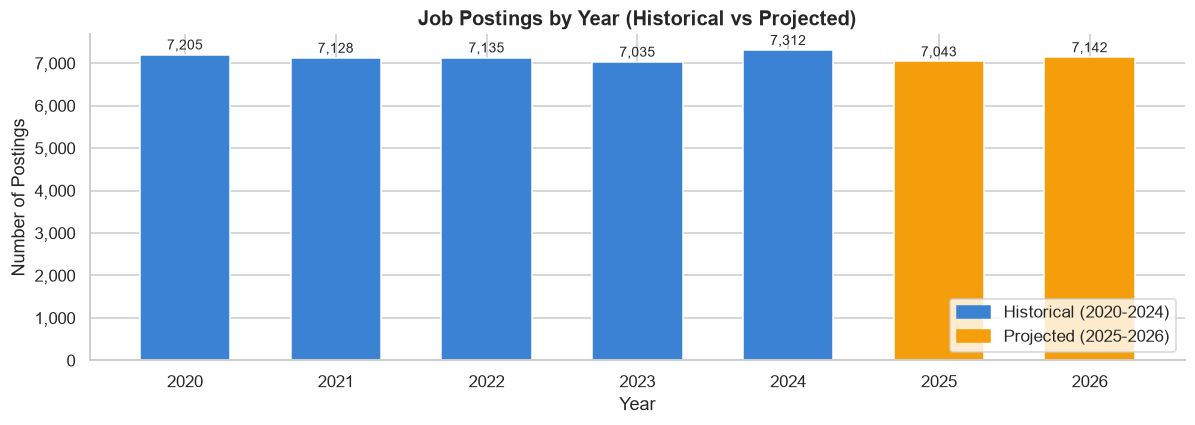

 posted_year period_type  count
        2020  Historical   7205
        2021  Historical   7128
        2022  Historical   7135
        2023  Historical   7035
        2024  Historical   7312
        2025   Projected   7043
        2026   Projected   7142


In [8]:
year_counts = jobs.groupby(['posted_year','period_type']).size().reset_index(name='count')

fig, ax = plt.subplots(figsize=(11, 4))
colors = [HIST_COLOR if p == 'Historical' else PROJ_COLOR
          for p in year_counts['period_type']]
bars = ax.bar(year_counts['posted_year'].astype(str), year_counts['count'], color=colors, edgecolor='white', width=0.6)
ax.set_title('Job Postings by Year (Historical vs Projected)', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Postings')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=HIST_COLOR, label='Historical (2020-2024)'),
                   Patch(color=PROJ_COLOR,  label='Projected (2025-2026)')],
          loc='lower right')
plt.tight_layout()
plt.show()
print(year_counts.to_string(index=False))

### B–C. Job Role & Role Category Distribution

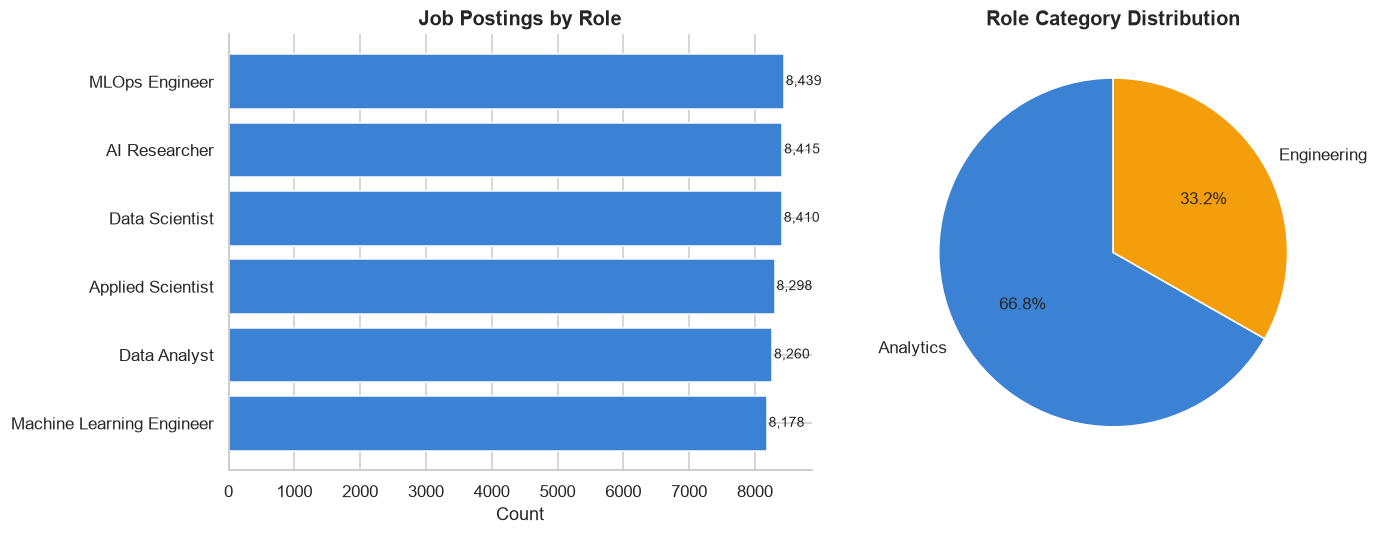

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# B. Job title
role_counts = jobs['job_title'].value_counts().sort_values()
axes[0].barh(role_counts.index, role_counts.values, color=HIST_COLOR)
axes[0].set_title('Job Postings by Role', fontweight='bold')
axes[0].set_xlabel('Count')
for i, v in enumerate(role_counts.values):
    axes[0].text(v + 30, i, f'{v:,}', va='center', fontsize=9)

# C. Role category
cat_counts = jobs['role_category'].value_counts()
axes[1].pie(cat_counts.values, labels=cat_counts.index, autopct='%1.1f%%',
            colors=[HIST_COLOR, PROJ_COLOR], startangle=90)
axes[1].set_title('Role Category Distribution', fontweight='bold')

plt.tight_layout()
plt.show()

### D–G. Country, Industry, Company Type & Size

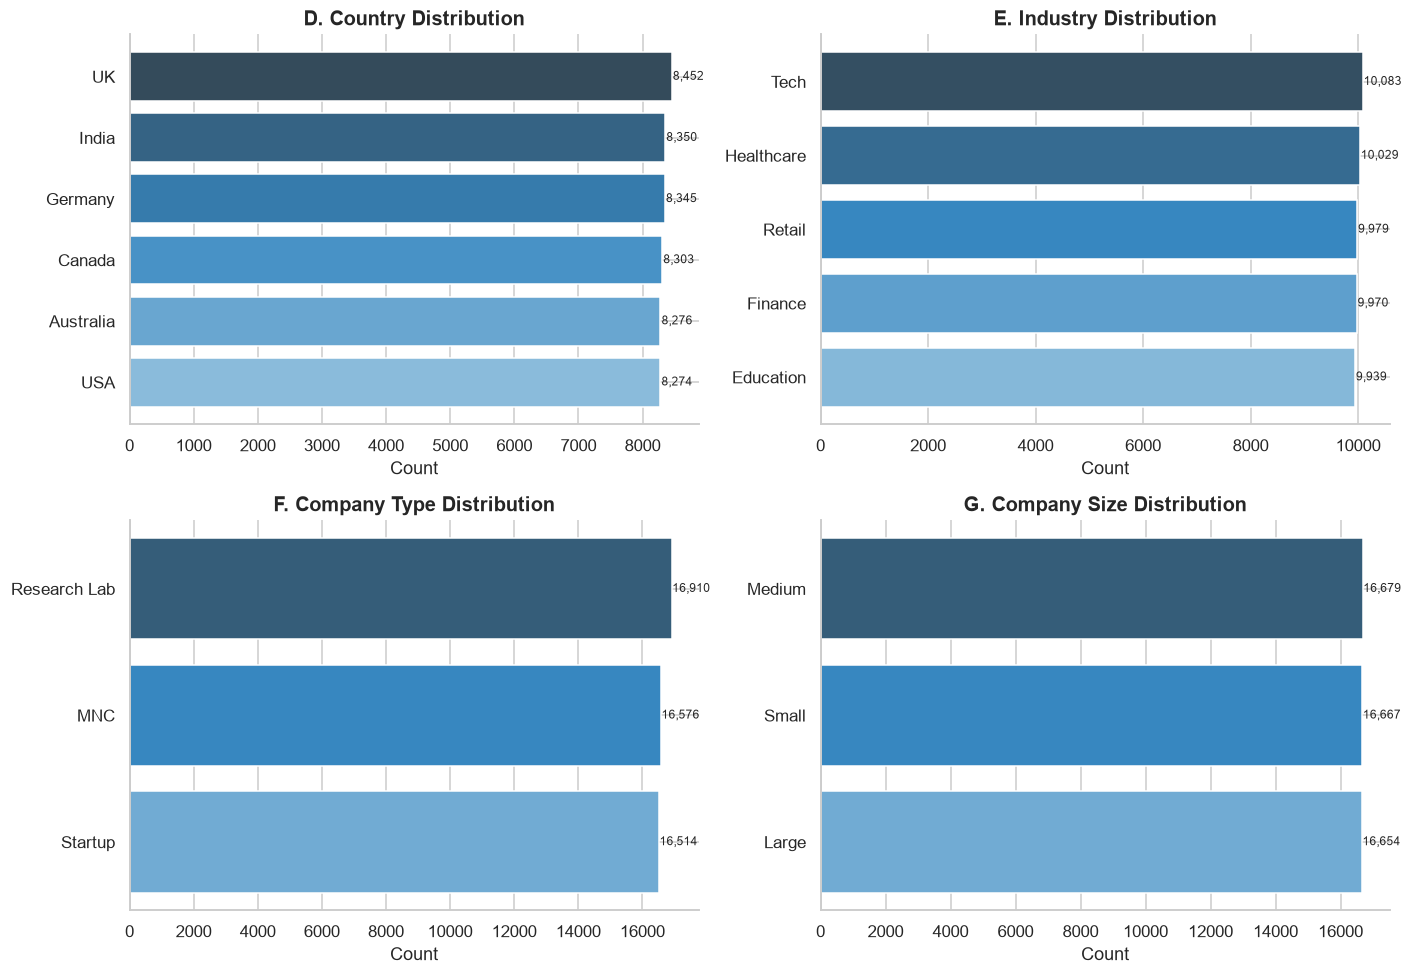

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
palette = sns.color_palette('tab10', 6)

dims = [
    ('country',      'D. Country Distribution',      axes[0,0]),
    ('industry',     'E. Industry Distribution',     axes[0,1]),
    ('company_type', 'F. Company Type Distribution', axes[1,0]),
    ('company_size', 'G. Company Size Distribution', axes[1,1]),
]

for col, title, ax in dims:
    counts = jobs[col].value_counts().sort_values(ascending=True)
    ax.barh(counts.index, counts.values,
            color=sns.color_palette('Blues_d', len(counts)))
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(v + 20, i, f'{v:,}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

### H–I. Remote Work & Experience Distribution

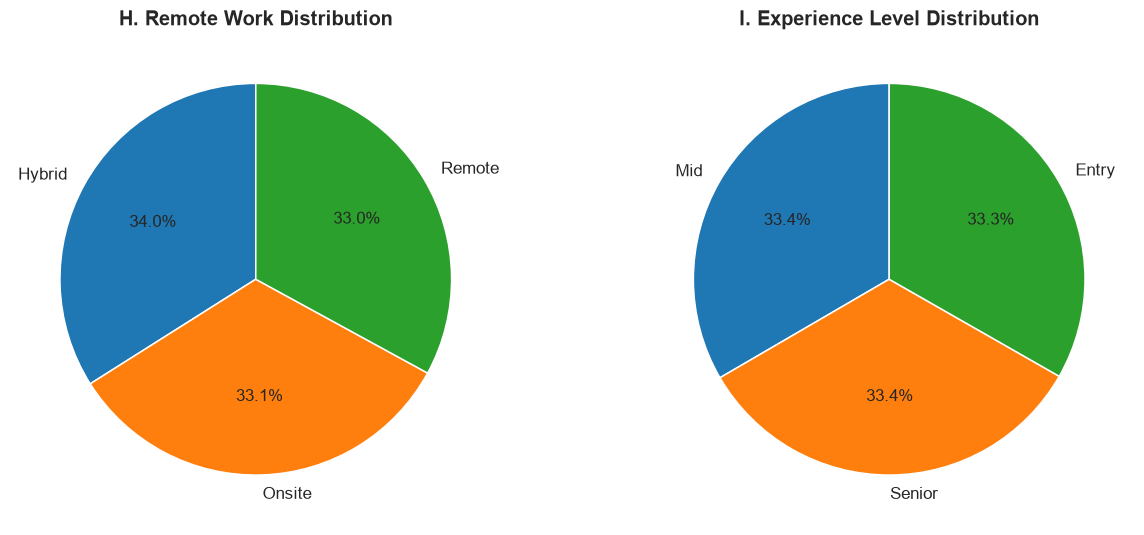

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col, title in [
    (axes[0], 'remote_type',      'H. Remote Work Distribution'),
    (axes[1], 'experience_level', 'I. Experience Level Distribution'),
]:
    counts = jobs[col].value_counts()
    ax.pie(counts.values, labels=counts.index, autopct='%1.1f%%',
           colors=sns.color_palette('tab10', len(counts)), startangle=90)
    ax.set_title(title, fontweight='bold')

plt.tight_layout()
plt.show()

### J. Salary Distribution

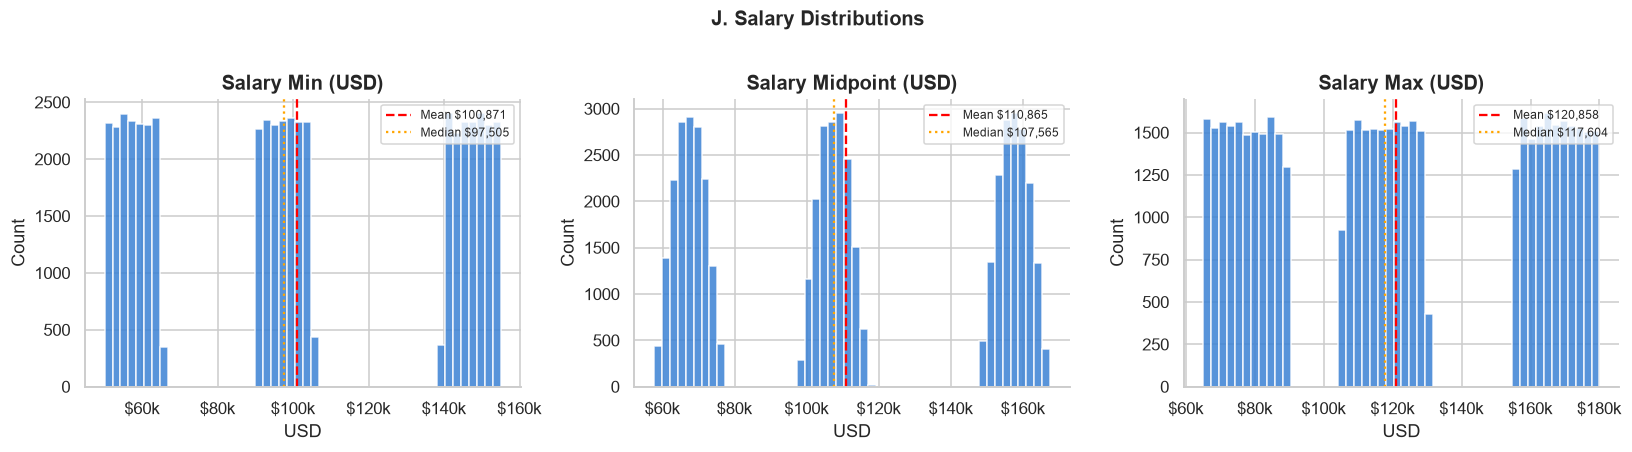


Salary Midpoint Summary:
count     $50,000
mean     $110,865
std       $37,049
min       $57,608
25%       $70,674
50%      $107,565
75%      $154,332
max      $167,468
Name: salary_mid, dtype: str


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, title in [
    (axes[0], 'salary_min_usd', 'Salary Min (USD)'),
    (axes[1], 'salary_mid',     'Salary Midpoint (USD)'),
    (axes[2], 'salary_max_usd', 'Salary Max (USD)'),
]:
    ax.hist(jobs[col], bins=50, color=HIST_COLOR, edgecolor='white', alpha=0.85)
    ax.axvline(jobs[col].mean(),   color='red',    linestyle='--', linewidth=1.5, label=f'Mean ${jobs[col].mean():,.0f}')
    ax.axvline(jobs[col].median(), color='orange', linestyle=':',  linewidth=1.5, label=f'Median ${jobs[col].median():,.0f}')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('USD')
    ax.set_ylabel('Count')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x/1000)}k'))
    ax.legend(fontsize=8)

plt.suptitle('J. Salary Distributions', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\nSalary Midpoint Summary:')
print(jobs['salary_mid'].describe().apply(lambda x: f'${x:,.0f}'))

---
## 12. Job Market Analysis

### Postings by Country and Year (Heatmap)

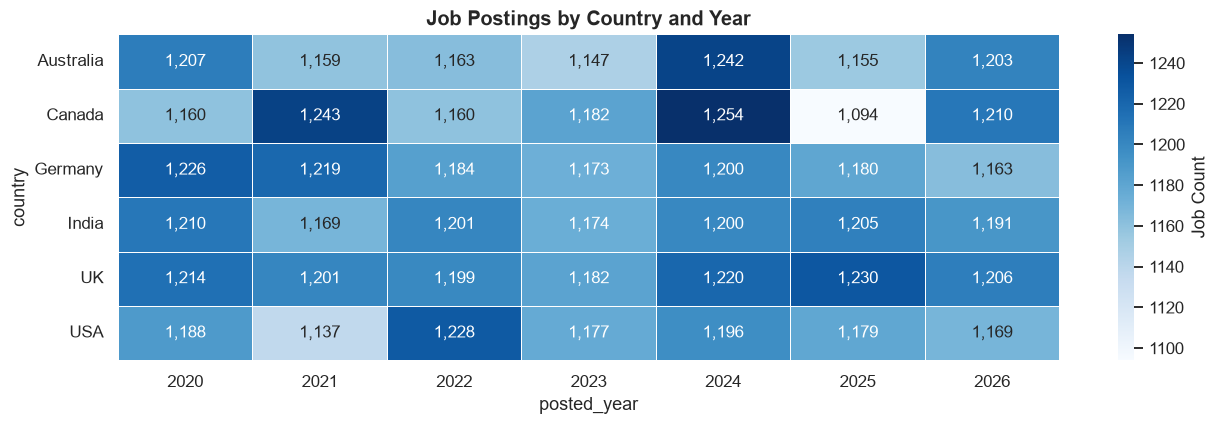

In [13]:
country_year = jobs.groupby(['country','posted_year']).size().reset_index(name='count')
pivot = country_year.pivot(index='country', columns='posted_year', values='count')

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(pivot, annot=True, fmt=',d', cmap='Blues', linewidths=0.5, ax=ax,
            cbar_kws={'label':'Job Count'})
ax.set_title('Job Postings by Country and Year', fontweight='bold')
plt.tight_layout(); plt.show()


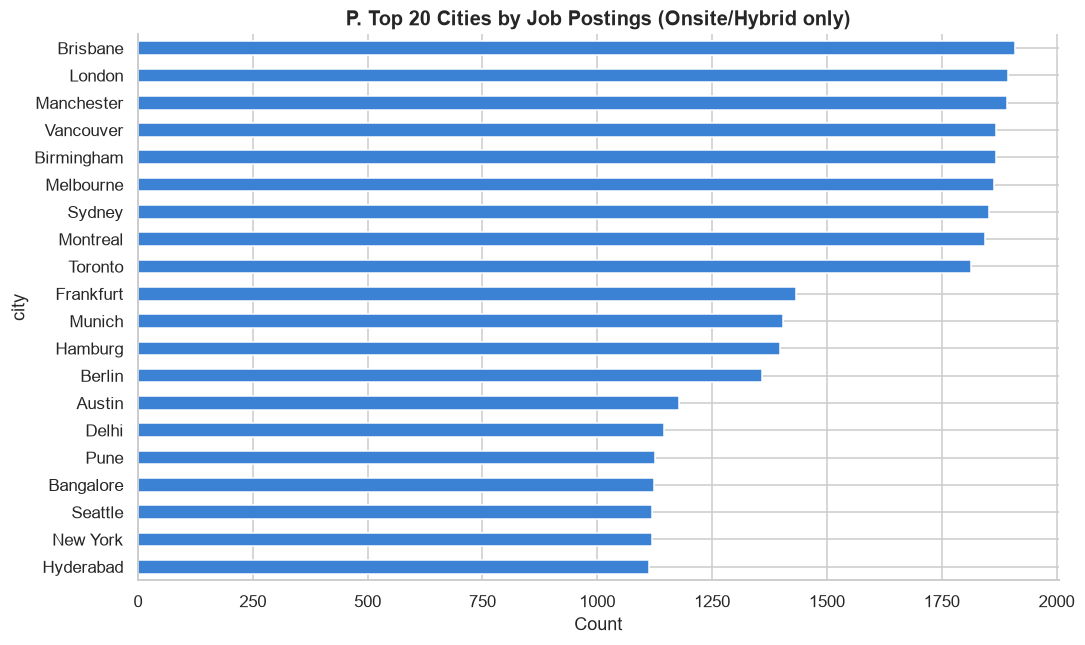

In [14]:
# P. City distribution (excluding city='Remote' entries)
city_counts = jobs[jobs['city'] != 'Remote']['city'].value_counts().head(20)
fig, ax = plt.subplots(figsize=(10, 6))
city_counts.sort_values().plot.barh(ax=ax, color=HIST_COLOR)
ax.set_title('P. Top 20 Cities by Job Postings (Onsite/Hybrid only)', fontweight='bold')
ax.set_xlabel('Count')
plt.tight_layout(); plt.show()


---
## 13. Salary Analysis

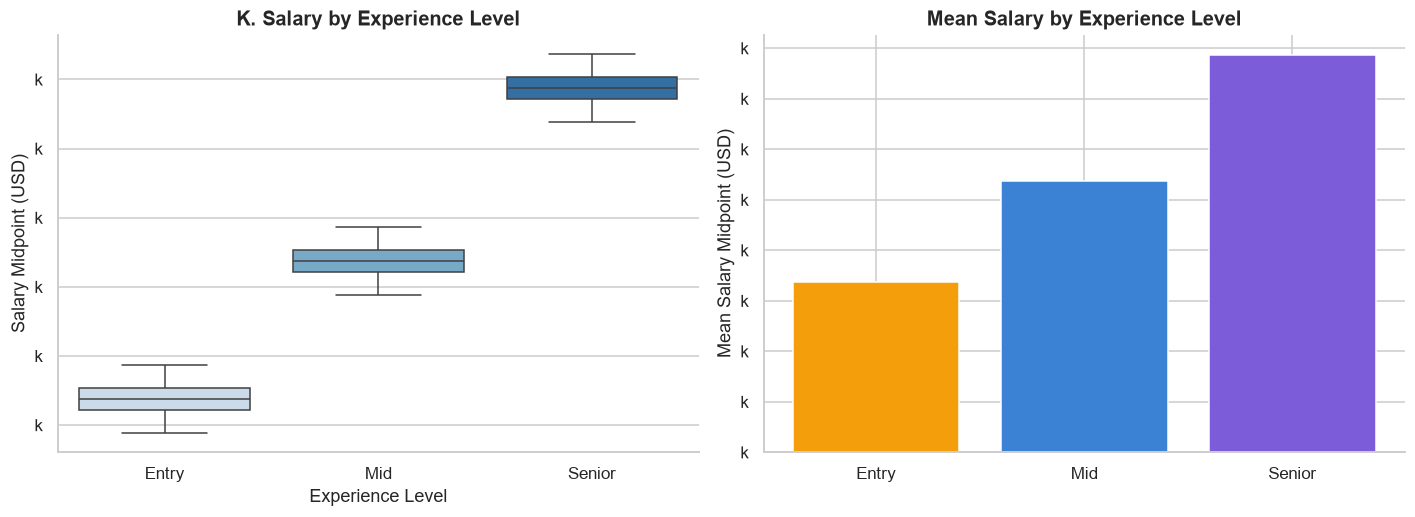

Mean salary_mid by experience_level:
                      mean    median     std
experience_level                            
Entry             67474.00  67470.00 4205.00
Mid              107507.00 107542.00 4190.00
Senior           157490.00 157468.00 4200.00


In [15]:
# K. Salary by experience level
order = ['Entry','Mid','Senior']
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=jobs, x='experience_level', y='salary_mid', order=order, ax=axes[0], palette='Blues')
axes[0].set_title('K. Salary by Experience Level', fontweight='bold')
axes[0].set_xlabel('Experience Level')
axes[0].set_ylabel('Salary Midpoint (USD)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'k'))

salary_exp = jobs.groupby('experience_level')['salary_mid'].mean().reindex(order)
axes[1].bar(salary_exp.index, salary_exp.values, color=[PROJ_COLOR, HIST_COLOR, '#7c5cd8'])
axes[1].set_title('Mean Salary by Experience Level', fontweight='bold')
axes[1].set_ylabel('Mean Salary Midpoint (USD)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'k'))
for i,(label,val) in enumerate(salary_exp.items()):
    axes[1].text(i, val+500, f'', ha='center', fontsize=10)
plt.suptitle('')
plt.tight_layout(); plt.show()
print('Mean salary_mid by experience_level:')
print(jobs.groupby('experience_level')['salary_mid'].agg(['mean','median','std']).round(0).reindex(order))


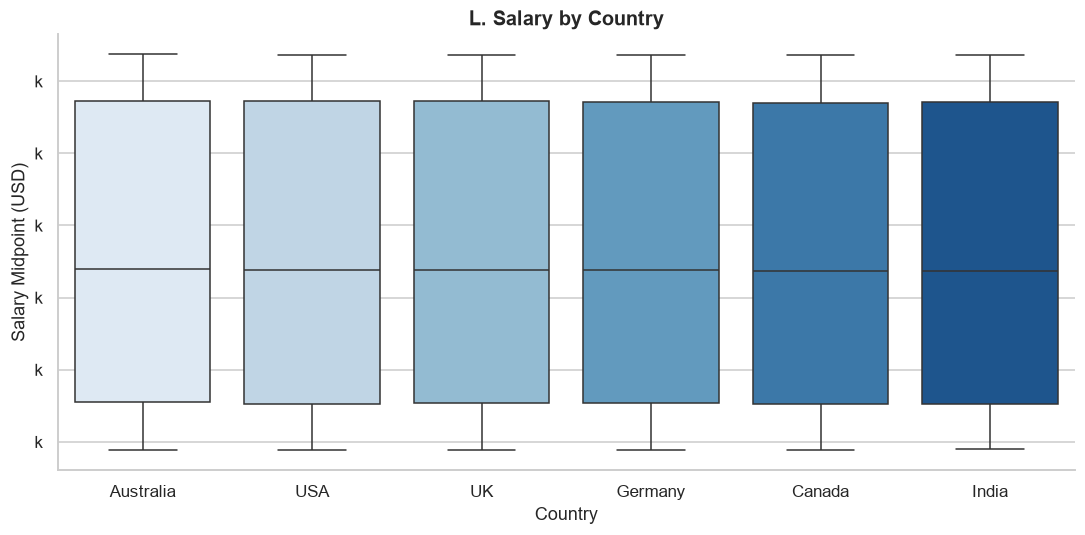

Mean salary_mid by country:
               mean    median
country                      
Australia 111485.00 107806.00
USA       111058.00 107686.00
UK        111039.00 107638.00
Germany   110898.00 107532.00
India     110397.00 107285.00
Canada    110314.00 107476.00


In [16]:
# L. Salary by country
order_c = jobs.groupby('country')['salary_mid'].median().sort_values(ascending=False).index.tolist()
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=jobs, x='country', y='salary_mid', order=order_c, ax=ax, palette='Blues')
ax.set_title('L. Salary by Country', fontweight='bold')
ax.set_xlabel('Country')
ax.set_ylabel('Salary Midpoint (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'k'))
plt.tight_layout(); plt.show()
print('Mean salary_mid by country:')
print(jobs.groupby('country')['salary_mid'].agg(['mean','median']).round(0).sort_values('mean',ascending=False))


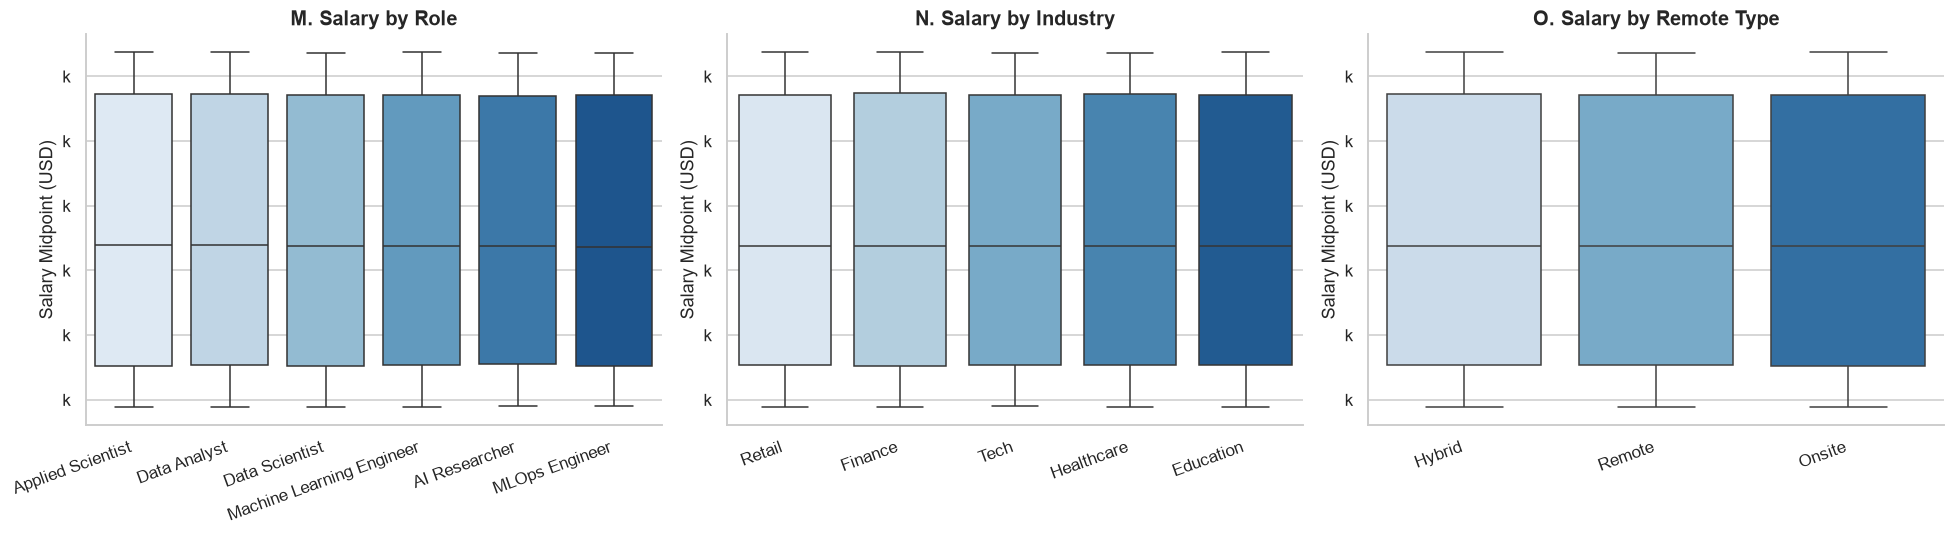

In [17]:
# M. Salary by job role  N. Salary by industry  O. Salary by remote type
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col, title in [
    (axes[0], 'job_title',   'M. Salary by Role'),
    (axes[1], 'industry',    'N. Salary by Industry'),
    (axes[2], 'remote_type', 'O. Salary by Remote Type'),
]:
    order_v = jobs.groupby(col)['salary_mid'].median().sort_values(ascending=False).index.tolist()
    sns.boxplot(data=jobs, x=col, y='salary_mid', order=order_v, ax=ax, palette='Blues')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Salary Midpoint (USD)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'k'))
    plt.setp(ax.xaxis.get_ticklabels(), rotation=20, ha='right')
plt.tight_layout(); plt.show()


---
## 14. Country Analysis

### T. Country AI Market Trends

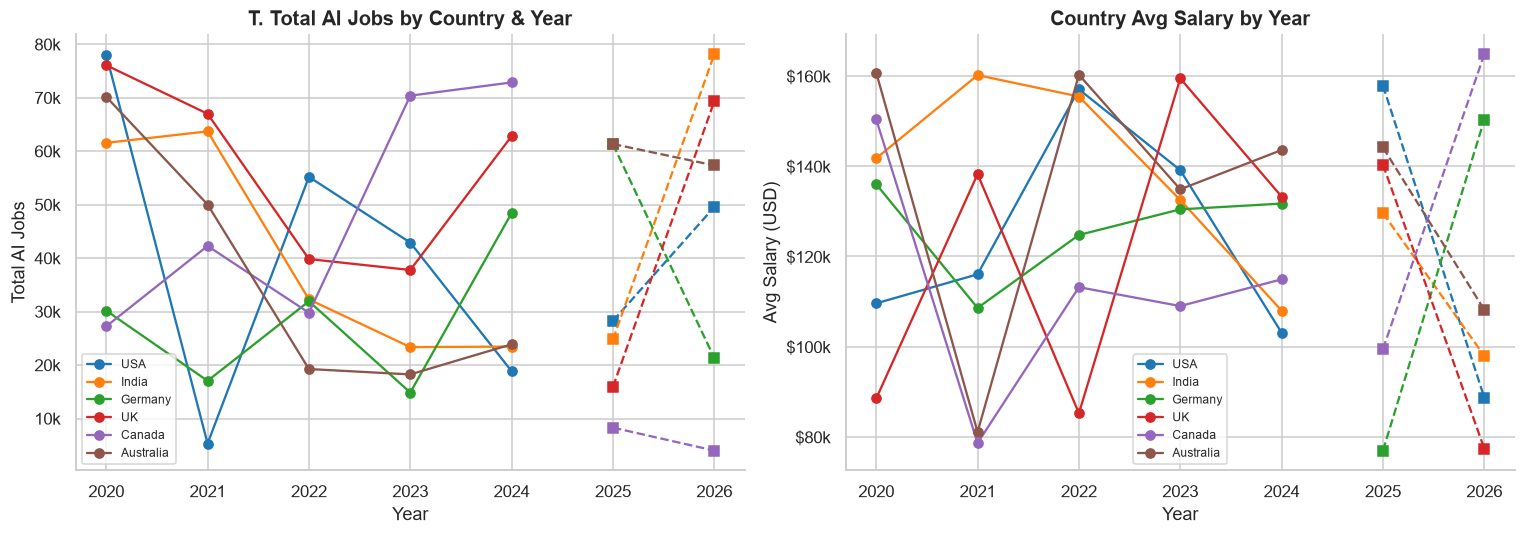

In [18]:
ct = country_trends_clean.copy()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for country_name in ct['country'].unique():
    sub = ct[ct['country']==country_name].sort_values('year')
    hist_sub = sub[sub['period_type']=='Historical']
    proj_sub = sub[sub['period_type']=='Projected']
    line = axes[0].plot(hist_sub['year'], hist_sub['total_ai_jobs'], marker='o', label=country_name)
    col = line[0].get_color()
    axes[0].plot(proj_sub['year'], proj_sub['total_ai_jobs'], marker='s', linestyle='--', color=col)

axes[0].set_title('T. Total AI Jobs by Country & Year', fontweight='bold')
axes[0].set_xlabel('Year'); axes[0].set_ylabel('Total AI Jobs')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x/1000)}k'))
axes[0].legend(fontsize=8)

for country_name in ct['country'].unique():
    sub = ct[ct['country']==country_name].sort_values('year')
    hist_sub = sub[sub['period_type']=='Historical']
    proj_sub = sub[sub['period_type']=='Projected']
    line = axes[1].plot(hist_sub['year'], hist_sub['avg_salary_usd'], marker='o', label=country_name)
    col = line[0].get_color()
    axes[1].plot(proj_sub['year'], proj_sub['avg_salary_usd'], marker='s', linestyle='--', color=col)

axes[1].set_title('Country Avg Salary by Year', fontweight='bold')
axes[1].set_xlabel('Year'); axes[1].set_ylabel('Avg Salary (USD)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${int(x/1000)}k'))
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()


### U. Remote Work % by Country and Year

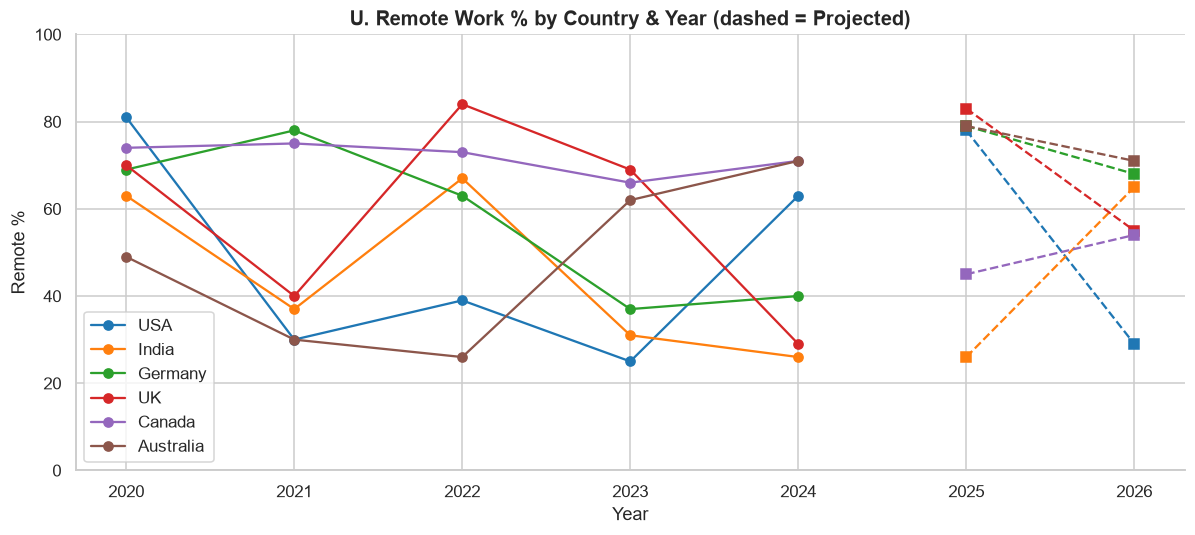

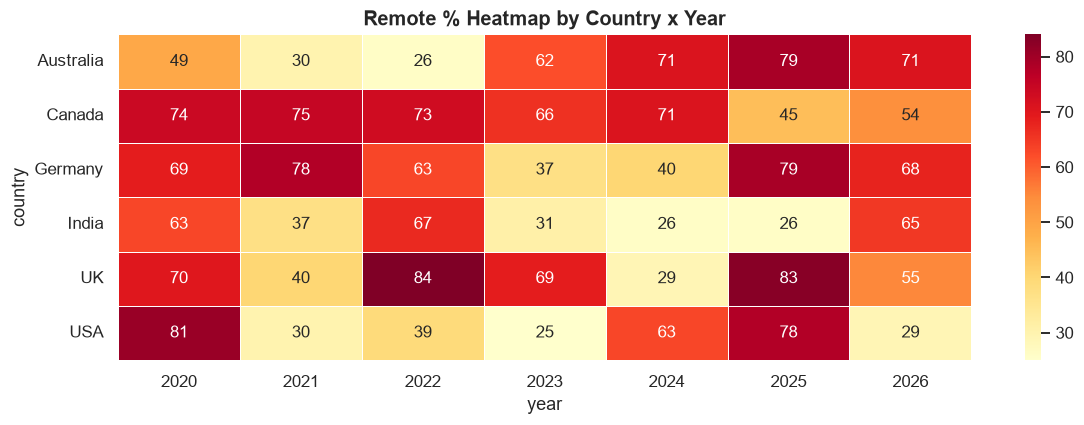

In [19]:
fig, ax = plt.subplots(figsize=(11, 5))
for country_name in ct['country'].unique():
    sub = ct[ct['country']==country_name].sort_values('year')
    hist_sub = sub[sub['period_type']=='Historical']
    proj_sub = sub[sub['period_type']=='Projected']
    line = ax.plot(hist_sub['year'], hist_sub['remote_percentage'], marker='o', label=country_name)
    col = line[0].get_color()
    ax.plot(proj_sub['year'], proj_sub['remote_percentage'], marker='s', linestyle='--', color=col)
ax.set_title('U. Remote Work % by Country & Year (dashed = Projected)', fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Remote %'); ax.set_ylim(0,100)
ax.legend(); plt.tight_layout(); plt.show()

pivot_r = ct.pivot(index='country', columns='year', values='remote_percentage')
fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(pivot_r, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5, ax=ax)
ax.set_title('Remote % Heatmap by Country x Year', fontweight='bold')
plt.tight_layout(); plt.show()


### V. Top Skill by Country and Year

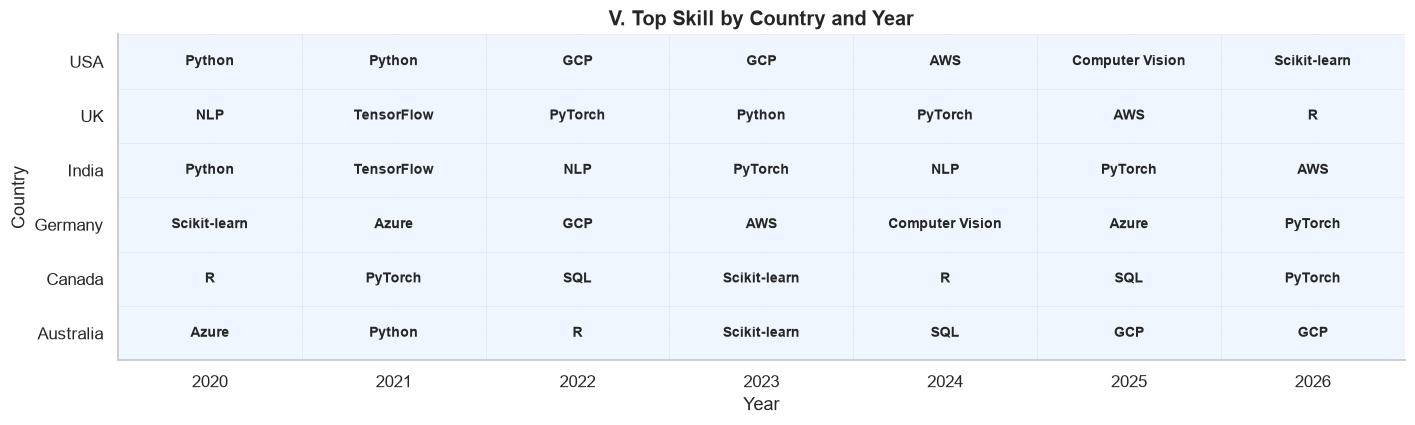

In [20]:
top_skill_pivot = ct.pivot(index='country', columns='year', values='top_skill')
fig, ax = plt.subplots(figsize=(13, 4))
ax.set_xlim(0, len(top_skill_pivot.columns))
ax.set_ylim(0, len(top_skill_pivot.index))
ax.set_xticks([i+0.5 for i in range(len(top_skill_pivot.columns))])
ax.set_xticklabels(top_skill_pivot.columns)
ax.set_yticks([i+0.5 for i in range(len(top_skill_pivot.index))])
ax.set_yticklabels(top_skill_pivot.index)
for i, country_name in enumerate(top_skill_pivot.index):
    for j, year_val in enumerate(top_skill_pivot.columns):
        skill_val = top_skill_pivot.loc[country_name, year_val]
        ax.text(j+0.5, i+0.5, str(skill_val), ha='center', va='center', fontsize=9, fontweight='bold')
        ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=True,
                     facecolor='#eff6ff', edgecolor='#e5e7eb', linewidth=0.5))
ax.set_title('V. Top Skill by Country and Year', fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Country')
plt.tight_layout(); plt.show()


---
## 15. Remote Work Analysis

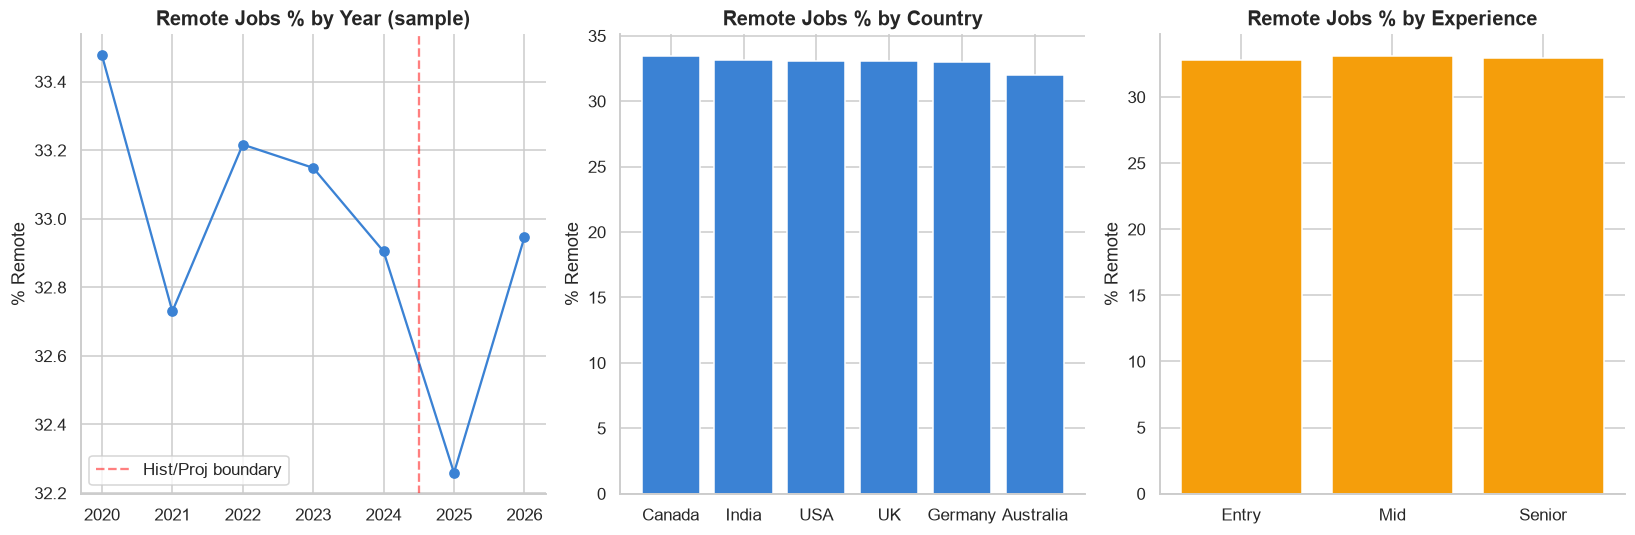

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

remote_year = jobs.groupby('posted_year')['remote_flag'].mean().mul(100)
axes[0].plot(remote_year.index, remote_year.values, marker='o', color=HIST_COLOR)
axes[0].axvline(2024.5, color='red', linestyle='--', alpha=0.5, label='Hist/Proj boundary')
axes[0].set_title('Remote Jobs % by Year (sample)', fontweight='bold')
axes[0].set_ylabel('% Remote'); axes[0].legend()

remote_country = jobs.groupby('country')['remote_flag'].mean().mul(100).sort_values(ascending=False)
axes[1].bar(remote_country.index, remote_country.values, color=HIST_COLOR)
axes[1].set_title('Remote Jobs % by Country', fontweight='bold')
axes[1].set_ylabel('% Remote')

remote_exp = jobs.groupby('experience_level')['remote_flag'].mean().mul(100).reindex(['Entry','Mid','Senior'])
axes[2].bar(remote_exp.index, remote_exp.values, color=PROJ_COLOR)
axes[2].set_title('Remote Jobs % by Experience', fontweight='bold')
axes[2].set_ylabel('% Remote')

plt.tight_layout(); plt.show()


---
## 16. Skills Intelligence

> **Note:** skills_demand cannot be directly joined to ai_jobs (only 4.1% job_id overlap — dataset artifact). Skills are analysed as an independent dataset.

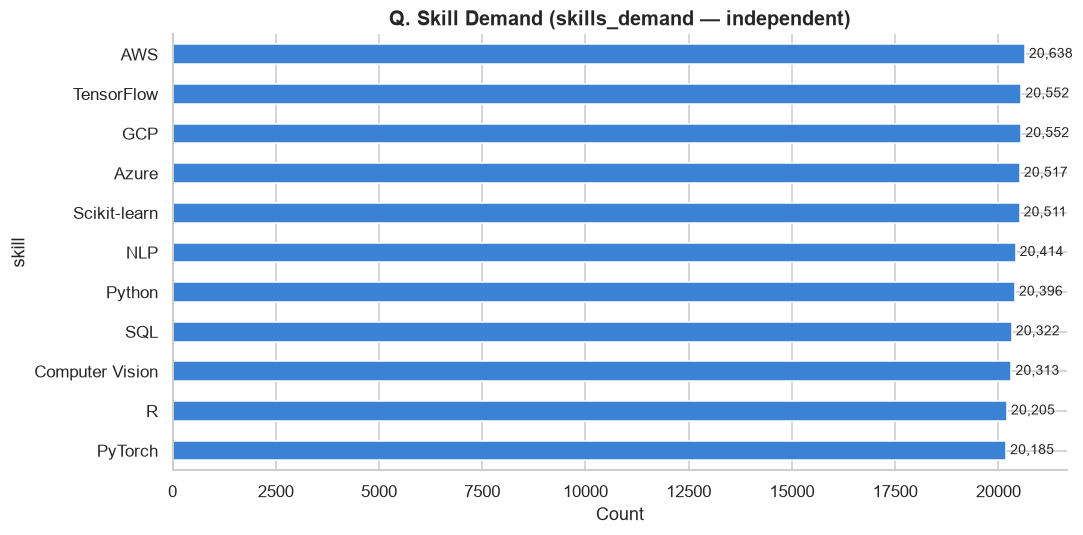

In [22]:
# Q. Skill frequency
skill_freq = skills_clean['skill'].value_counts()
fig, ax = plt.subplots(figsize=(10, 5))
skill_freq.sort_values().plot.barh(ax=ax, color=HIST_COLOR)
ax.set_title('Q. Skill Demand (skills_demand — independent)', fontweight='bold')
ax.set_xlabel('Count')
for i, v in enumerate(skill_freq.sort_values().values):
    ax.text(v+100, i, f'{v:,}', va='center', fontsize=9)
plt.tight_layout(); plt.show()


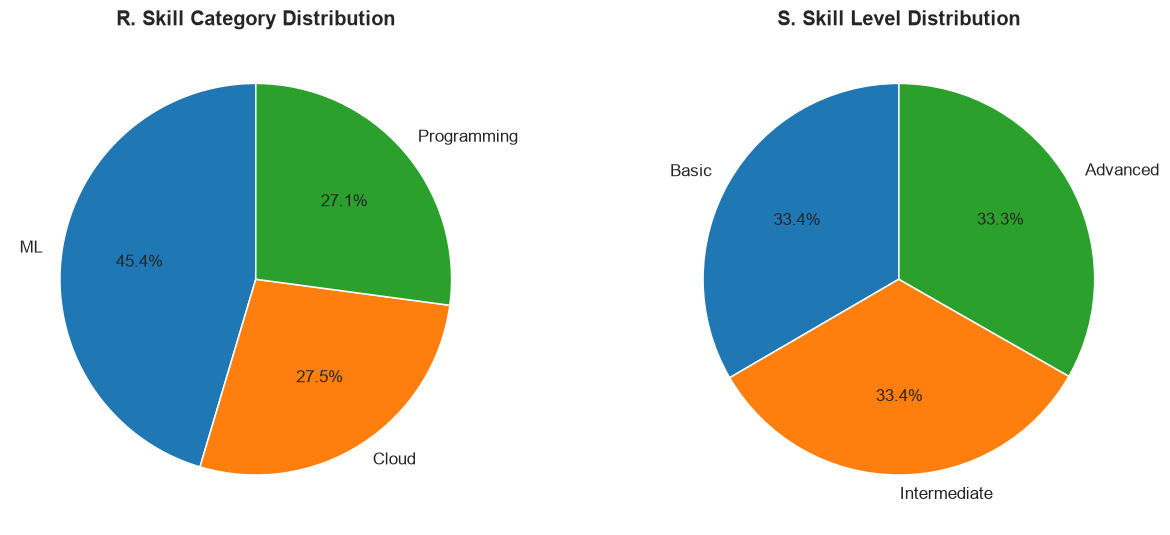

            summary_type           value  count   pct
         skill_frequency             AWS  20638  9.19
         skill_frequency             GCP  20552  9.15
         skill_frequency      TensorFlow  20552  9.15
         skill_frequency           Azure  20517  9.13
         skill_frequency    Scikit-learn  20511  9.13
         skill_frequency             NLP  20414  9.09
         skill_frequency          Python  20396  9.08
         skill_frequency             SQL  20322  9.05
         skill_frequency Computer Vision  20313  9.04
         skill_frequency               R  20205  9.00
         skill_frequency         PyTorch  20185  8.99
skill_category_frequency              ML 101975 45.40
skill_category_frequency           Cloud  61707 27.47
skill_category_frequency     Programming  60923 27.12
   skill_level_frequency           Basic  74992 33.39
   skill_level_frequency    Intermediate  74920 33.36
   skill_level_frequency        Advanced  74693 33.26


In [23]:
# R. Skill category  S. Skill level
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, col, title in [
    (axes[0], 'skill_category', 'R. Skill Category Distribution'),
    (axes[1], 'skill_level',    'S. Skill Level Distribution'),
]:
    counts = skills_clean[col].value_counts()
    ax.pie(counts.values, labels=counts.index, autopct='%1.1f%%',
           colors=sns.color_palette('tab10', len(counts)), startangle=90)
    ax.set_title(title, fontweight='bold')
plt.tight_layout(); plt.show()
print(skill_summary.to_string(index=False))


---
## 17. Historical vs Projected Analysis

Historical rows (2020-2024) : 35,815  (71.6%)
Projected rows  (2025-2026) : 14,185  (28.4%)

Salary midpoint comparison:
  Historical: mean=$110,950  median=$107,590
  Projected: mean=$110,650  median=$107,467


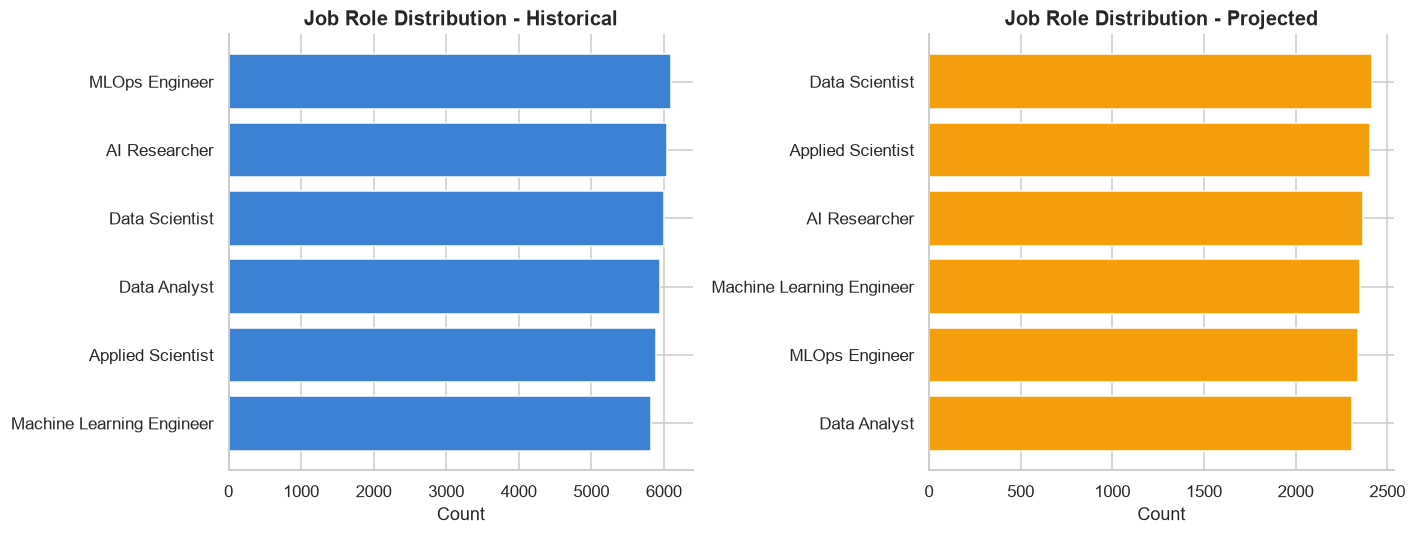

In [24]:
hist_jobs = jobs[jobs['period_type'] == 'Historical']
proj_jobs  = jobs[jobs['period_type'] == 'Projected']

print(f'Historical rows (2020-2024) : {len(hist_jobs):,}  ({100*len(hist_jobs)/len(jobs):.1f}%)')
print(f'Projected rows  (2025-2026) : {len(proj_jobs):,}  ({100*len(proj_jobs)/len(jobs):.1f}%)')

print('\nSalary midpoint comparison:')
for period, group in jobs.groupby('period_type'):
    print(f'  {period}: mean=${group["salary_mid"].mean():,.0f}  median=${group["salary_mid"].median():,.0f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, period, color in [(axes[0],'Historical',HIST_COLOR),(axes[1],'Projected',PROJ_COLOR)]:
    subset = jobs[jobs['period_type']==period]
    counts = subset['job_title'].value_counts().sort_values()
    ax.barh(counts.index, counts.values, color=color)
    ax.set_title(f'Job Role Distribution - {period}', fontweight='bold')
    ax.set_xlabel('Count')
plt.tight_layout(); plt.show()


---
## 18. Statistical Analysis

All tests use alpha = 0.05.

In [25]:
from scipy.stats import normaltest, kruskal
import pandas as pd
alpha = 0.05

stat_n, p_n = normaltest(jobs['salary_mid'])
print("1. Normality (D'Agostino-Pearson) on salary_mid:")
print(f'   stat={stat_n:.2f}, p={p_n:.4e}')
print(f'   -> salary_mid is {"NOT normally distributed" if p_n<alpha else "approximately normal"}')
print('   -> Using Kruskal-Wallis (non-parametric) for group comparisons.\n')

tests = [
    ('experience_level', 'Salary vs Experience Level'),
    ('country',          'Salary vs Country'),
    ('industry',         'Salary vs Industry'),
    ('remote_type',      'Salary vs Remote Type'),
    ('role_category',    'Salary vs Role Category'),
    ('company_type',     'Salary vs Company Type'),
    ('company_size',     'Salary vs Company Size'),
]

test_results = []
for col, label in tests:
    groups = [g['salary_mid'].values for _, g in jobs.groupby(col)]
    H, p = kruskal(*groups)
    sig = p < alpha
    result_str = 'SIGNIFICANT' if sig else 'not significant'
    print(f'{label:<35} H={H:8.2f}  p={p:.4e}  [{result_str}]')
    test_results.append({'Factor': label, 'H': round(H,2), 'p-value': round(p,6), 'Significant (p<0.05)': sig})

results_table = pd.DataFrame(test_results)
print()
print(results_table.to_string(index=False))


1. Normality (D'Agostino-Pearson) on salary_mid:
   stat=339741.81, p=0.0000e+00
   -> salary_mid is NOT normally distributed
   -> Using Kruskal-Wallis (non-parametric) for group comparisons.

Salary vs Experience Level          H=44443.51  p=0.0000e+00  [SIGNIFICANT]
Salary vs Country                   H=    5.33  p=3.7669e-01  [not significant]
Salary vs Industry                  H=    0.75  p=9.4465e-01  [not significant]
Salary vs Remote Type               H=    2.59  p=2.7396e-01  [not significant]
Salary vs Role Category             H=    2.20  p=1.3798e-01  [not significant]


Salary vs Company Type              H=    2.84  p=2.4141e-01  [not significant]
Salary vs Company Size              H=    0.05  p=9.7420e-01  [not significant]

                    Factor        H  p-value  Significant (p<0.05)
Salary vs Experience Level 44443.51     0.00                  True
         Salary vs Country     5.33     0.38                 False
        Salary vs Industry     0.75     0.94                 False
     Salary vs Remote Type     2.59     0.27                 False
   Salary vs Role Category     2.20     0.14                 False
    Salary vs Company Type     2.84     0.24                 False
    Salary vs Company Size     0.05     0.97                 False


---
## 19. Machine Learning

### A. Salary Regression

> **Educational Note:** This dataset is synthetically generated. Only `experience_level` carries meaningful salary signal. All models serve as demonstrations.

In [26]:
from src.feature_engineering import build_ml_feature_matrix, add_salary_features, add_experience_numeric, add_period_type
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Prepare ML dataset from historical data only
jobs_ml = jobs_clean.copy()
jobs_ml = add_salary_features(jobs_ml)
jobs_ml = add_experience_numeric(jobs_ml)
jobs_ml = add_period_type(jobs_ml)
jobs_hist_ml = jobs_ml[jobs_ml['period_type'] == 'Historical'].copy()
TARGET = 'salary_mid'

X_full, y, features = build_ml_feature_matrix(jobs_hist_ml, target=TARGET)
print(f'Training rows: {len(jobs_hist_ml):,} (Historical 2020-2024 only)')
print(f'Feature matrix: {X_full.shape}')
print(f'Features: {features}')


Training rows: 35,815 (Historical 2020-2024 only)
Feature matrix: (35815, 24)
Features: ['posted_year', 'job_title_Applied Scientist', 'job_title_Data Analyst', 'job_title_Data Scientist', 'job_title_MLOps Engineer', 'job_title_Machine Learning Engineer', 'company_type_Research Lab', 'company_type_Startup', 'industry_Finance', 'industry_Healthcare', 'industry_Retail', 'industry_Tech', 'country_Canada', 'country_Germany', 'country_India', 'country_UK', 'country_USA', 'remote_type_Onsite', 'remote_type_Remote', 'experience_level_Mid', 'experience_level_Senior', 'company_size_Medium', 'company_size_Small', 'role_category_Engineering']


In [27]:
# Train/test split — stratify on experience_level for balance
strat_col = jobs_hist_ml['experience_level'].values
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y, test_size=0.2, random_state=42, stratify=strat_col)

# BASELINE: experience_level encoded as 0/1/2 only
exp_map = {'Entry':0,'Mid':1,'Senior':2}
X_base = jobs_hist_ml['experience_level'].map(exp_map).values.reshape(-1,1)
X_base_train, X_base_test, y_base_train, y_base_test = train_test_split(
    X_base, y, test_size=0.2, random_state=42, stratify=strat_col)

print(f'Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}')


Train: 28,652  |  Test: 7,163


In [28]:
def evaluate_model(model, X_tr, y_tr, X_te, y_te, label):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    mae  = mean_absolute_error(y_te, preds)
    rmse = np.sqrt(mean_squared_error(y_te, preds))
    r2   = r2_score(y_te, preds)
    print(f'  {label:<42} MAE=${mae:>8,.0f}  RMSE=${rmse:>8,.0f}  R2={r2:.4f}')
    return {'label':label, 'MAE':round(mae,0), 'RMSE':round(rmse,0), 'R2':round(r2,4),
            'model':model, 'preds':preds, 'y_test':y_te}

print('=== BASELINE: experience_level only ===')
lr_base = evaluate_model(LinearRegression(), X_base_train, y_base_train, X_base_test, y_base_test, 'LinearRegression (baseline)')

print()
print('=== FULL FEATURE MODELS ===')
lr_full = evaluate_model(LinearRegression(),                                        X_train, y_train, X_test, y_test, 'LinearRegression (full features)')
rf_full = evaluate_model(RandomForestRegressor(n_estimators=100,random_state=42,n_jobs=-1), X_train, y_train, X_test, y_test, 'RandomForest (full features)')
gb_full = evaluate_model(GradientBoostingRegressor(n_estimators=100,random_state=42),       X_train, y_train, X_test, y_test, 'GradientBoosting (full features)')


=== BASELINE: experience_level only ===
  LinearRegression (baseline)                MAE=$   3,921  RMSE=$   4,791  R2=0.9834

=== FULL FEATURE MODELS ===
  LinearRegression (full features)           MAE=$   3,477  RMSE=$   4,170  R2=0.9874


  RandomForest (full features)               MAE=$   3,777  RMSE=$   4,606  R2=0.9846


  GradientBoosting (full features)           MAE=$   3,481  RMSE=$   4,175  R2=0.9874


In [29]:
import pandas as pd
model_comparison = pd.DataFrame([
    {'Model': lr_base['label'], 'Feature Set': 'experience only', 'MAE': lr_base['MAE'], 'RMSE': lr_base['RMSE'], 'R2': lr_base['R2']},
    {'Model': lr_full['label'], 'Feature Set': 'all valid features', 'MAE': lr_full['MAE'], 'RMSE': lr_full['RMSE'], 'R2': lr_full['R2']},
    {'Model': rf_full['label'], 'Feature Set': 'all valid features', 'MAE': rf_full['MAE'], 'RMSE': rf_full['RMSE'], 'R2': rf_full['R2']},
    {'Model': gb_full['label'], 'Feature Set': 'all valid features', 'MAE': gb_full['MAE'], 'RMSE': gb_full['RMSE'], 'R2': gb_full['R2']},
])
print('Model Comparison:')
print(model_comparison[['Model','Feature Set','MAE','RMSE','R2']].to_string(index=False))


Model Comparison:
                           Model        Feature Set     MAE    RMSE   R2
     LinearRegression (baseline)    experience only 3921.00 4791.00 0.98
LinearRegression (full features) all valid features 3477.00 4170.00 0.99
    RandomForest (full features) all valid features 3777.00 4606.00 0.98
GradientBoosting (full features) all valid features 3481.00 4175.00 0.99


---
## 20. Model Evaluation — Residual Analysis

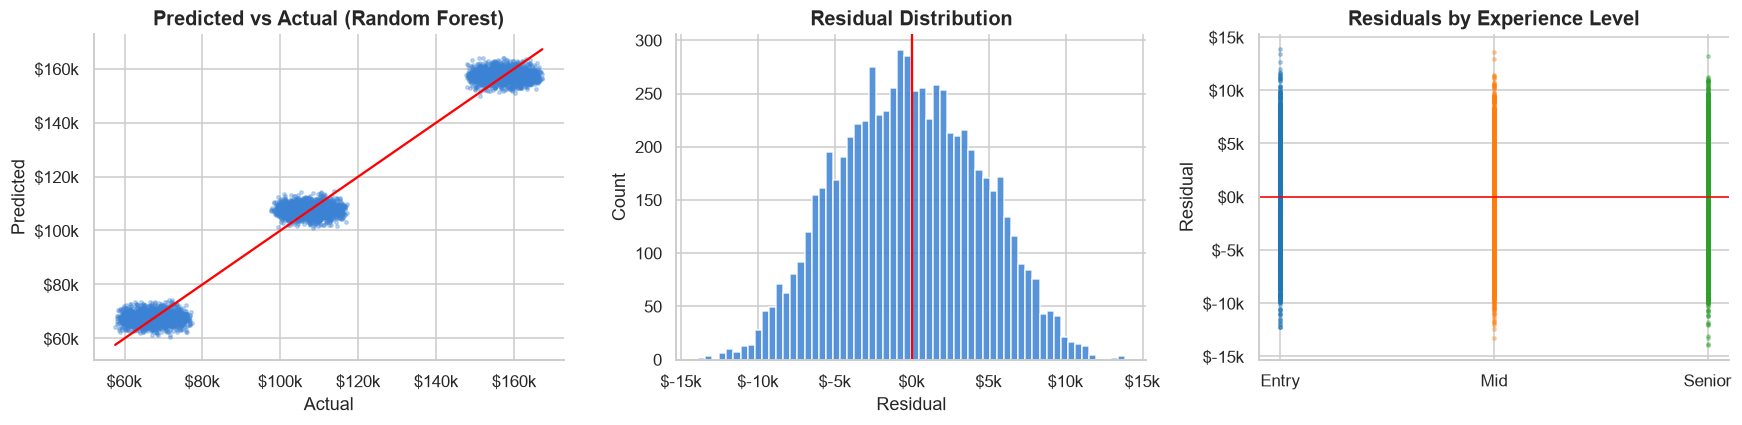

In [30]:
best_model_result = rf_full
y_pred_best  = best_model_result['preds']
y_test_vals  = best_model_result['y_test'].values
residuals    = y_test_vals - y_pred_best

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Predicted vs Actual
axes[0].scatter(y_test_vals, y_pred_best, alpha=0.3, color=HIST_COLOR, s=5)
lim = [min(y_test_vals.min(), y_pred_best.min()), max(y_test_vals.max(), y_pred_best.max())]
axes[0].plot(lim, lim, color='red', linewidth=1.5)
axes[0].set_title('Predicted vs Actual (Random Forest)', fontweight='bold')
axes[0].set_xlabel('Actual'); axes[0].set_ylabel('Predicted')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${int(x/1000)}k'))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${int(x/1000)}k'))

# Residuals histogram
axes[1].hist(residuals, bins=60, color=HIST_COLOR, edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', linewidth=1.5)
axes[1].set_title('Residual Distribution', fontweight='bold')
axes[1].set_xlabel('Residual'); axes[1].set_ylabel('Count')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${int(x/1000)}k'))

# Residuals by experience level
exp_col = jobs_hist_ml.loc[best_model_result['y_test'].index, 'experience_level']
exp_order = ['Entry','Mid','Senior']
for i, exp in enumerate(exp_order):
    mask = exp_col == exp
    if mask.sum() > 0:
        axes[2].scatter([i]*mask.sum(), residuals[mask.values], alpha=0.3, s=5, label=exp)
axes[2].axhline(0, color='red', linewidth=1)
axes[2].set_xticks([0,1,2]); axes[2].set_xticklabels(exp_order)
axes[2].set_title('Residuals by Experience Level', fontweight='bold')
axes[2].set_ylabel('Residual')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${int(x/1000)}k'))

plt.tight_layout(); plt.show()


---
## 21. Feature Importance / Model Interpretation

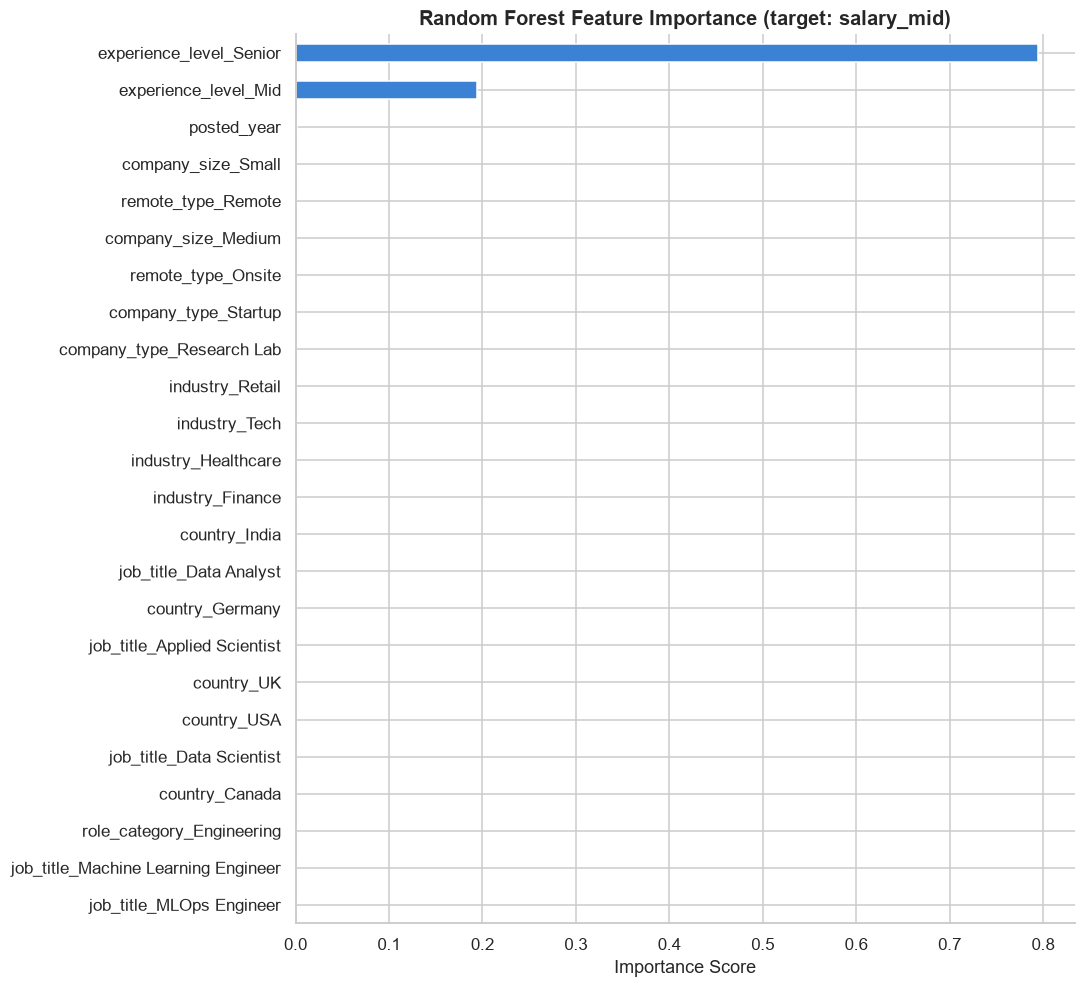

Top features by importance:
experience_level_Senior     0.79
experience_level_Mid        0.19
posted_year                 0.00
company_size_Small          0.00
remote_type_Remote          0.00
company_size_Medium         0.00
remote_type_Onsite          0.00
company_type_Startup        0.00
company_type_Research Lab   0.00
industry_Retail             0.00

Interpretation:
  Experience-level features dominate due to synthetic uniform distribution.
  In real data, geography and industry would also contribute meaningfully.


In [31]:
rf_model = rf_full['model']
feat_importance = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, max(4, len(feat_importance)*0.38)))
feat_importance.sort_values().plot.barh(ax=ax, color=HIST_COLOR)
ax.set_title('Random Forest Feature Importance (target: salary_mid)', fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout(); plt.show()

print('Top features by importance:')
print(feat_importance.head(10).round(4).to_string())
print()
print('Interpretation:')
print('  Experience-level features dominate due to synthetic uniform distribution.')
print('  In real data, geography and industry would also contribute meaningfully.')


---
## 22. Clustering

### B. Unsupervised Clustering — Job Profile Segmentation

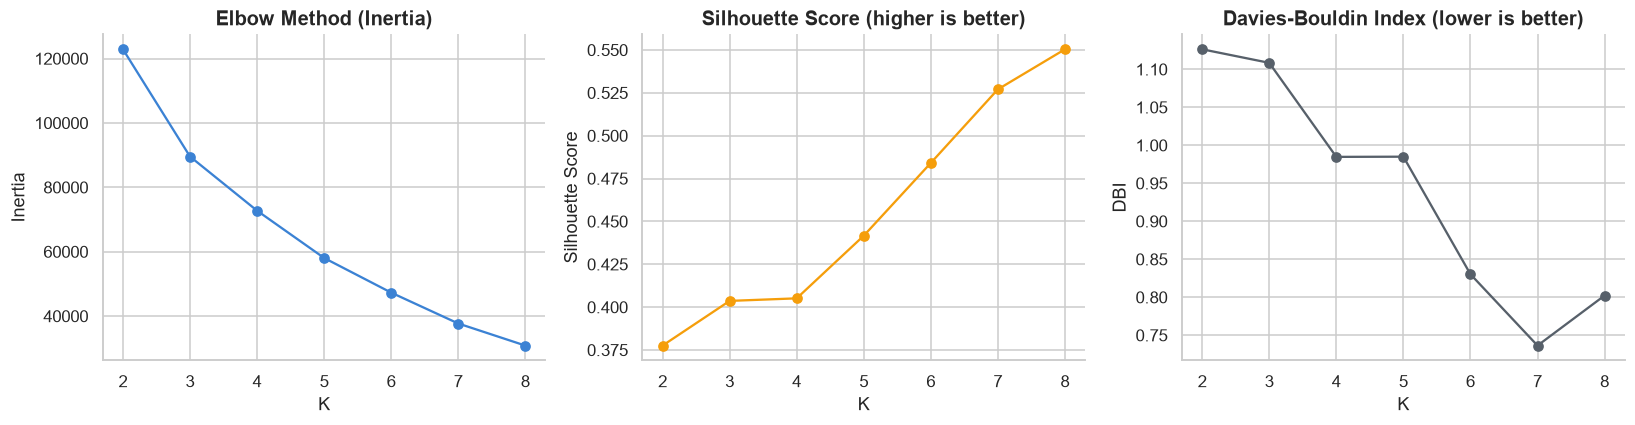

Best K by Silhouette: 8 (score=0.5504)
Best K by DBI       : 7 (score=0.7363)


In [32]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score

cluster_features = ['salary_mid', 'experience_numeric', 'remote_flag', 'company_size_numeric']
X_clust_raw = jobs[cluster_features].dropna()

scaler = StandardScaler()
X_clust = scaler.fit_transform(X_clust_raw)

k_range = range(2, 9)
inertias, silhouettes, dbis = [], [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_clust)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_clust, labels))
    dbis.append(davies_bouldin_score(X_clust, labels))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(list(k_range), inertias, marker='o', color=HIST_COLOR)
axes[0].set_title('Elbow Method (Inertia)', fontweight='bold')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Inertia')

axes[1].plot(list(k_range), silhouettes, marker='o', color=PROJ_COLOR)
axes[1].set_title('Silhouette Score (higher is better)', fontweight='bold')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Silhouette Score')

axes[2].plot(list(k_range), dbis, marker='o', color=NEUTRAL)
axes[2].set_title('Davies-Bouldin Index (lower is better)', fontweight='bold')
axes[2].set_xlabel('K'); axes[2].set_ylabel('DBI')

plt.tight_layout(); plt.show()

best_k = list(k_range)[silhouettes.index(max(silhouettes))]
print(f'Best K by Silhouette: {best_k} (score={max(silhouettes):.4f})')
print(f'Best K by DBI       : {list(k_range)[dbis.index(min(dbis))]} (score={min(dbis):.4f})')


Cluster Profile (K=8):
         salary_mean  salary_median  count  avg_exp  remote_pct  avg_company_size
cluster                                                                          
0           80891.65       70709.00   5493     0.34        1.00              2.66
1          132625.29      148429.50   7481     1.50        0.00              3.00
2          157485.79      157364.00   7426     2.00        0.00              1.50
3           67513.15       67507.50   7438     0.00        0.00              1.50
4          157481.20      157510.75   5498     2.00        1.00              2.00
5          107468.90      107563.50   7445     1.00        0.00              1.49
6           94298.60      104324.50   5487     0.67        1.00              1.33
7           67451.94       67467.50   3732     0.00        0.00              3.00


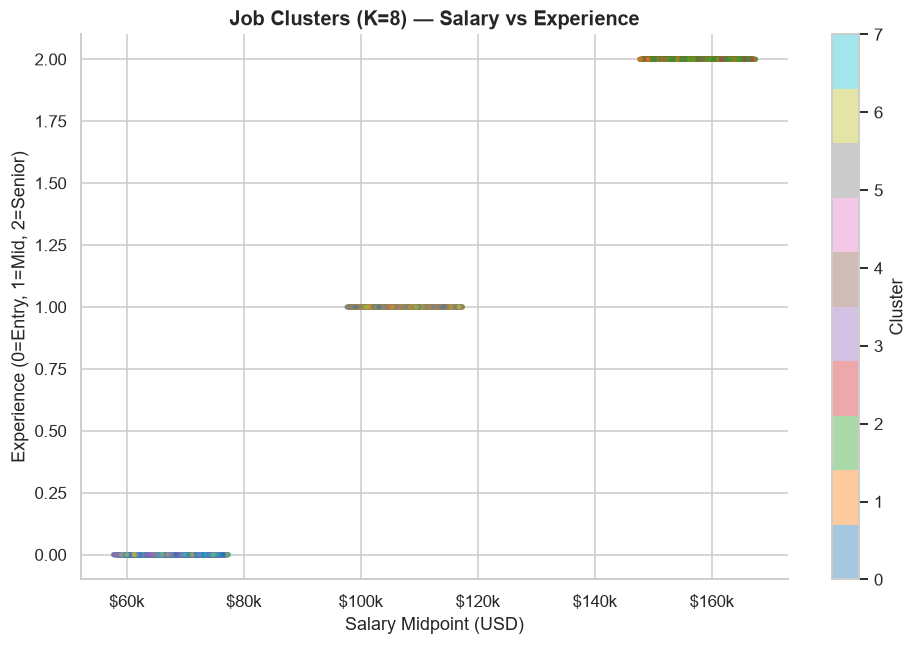

In [33]:
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = km_final.fit_predict(X_clust)

jobs_clust = X_clust_raw.copy()
jobs_clust['cluster'] = cluster_labels
jobs_clust['experience_level'] = jobs.loc[X_clust_raw.index, 'experience_level'].values

cluster_profile = jobs_clust.groupby('cluster').agg(
    salary_mean=('salary_mid','mean'),
    salary_median=('salary_mid','median'),
    count=('salary_mid','count'),
    avg_exp=('experience_numeric','mean'),
    remote_pct=('remote_flag','mean'),
    avg_company_size=('company_size_numeric','mean')
).round(2)

print(f'Cluster Profile (K={best_k}):')
print(cluster_profile.to_string())

fig, ax = plt.subplots(figsize=(9, 6))
scatter = ax.scatter(
    X_clust_raw['salary_mid'], X_clust_raw['experience_numeric'],
    c=cluster_labels, cmap='tab10', alpha=0.4, s=5)
ax.set_xlabel('Salary Midpoint (USD)')
ax.set_ylabel('Experience (0=Entry, 1=Mid, 2=Senior)')
ax.set_title(f'Job Clusters (K={best_k}) — Salary vs Experience', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${int(x/1000)}k'))
plt.colorbar(scatter, label='Cluster', ax=ax)
plt.tight_layout(); plt.show()


---
## 23. Key Insights

In [34]:
print('=== KEY INSIGHTS ===')
print()
print('1. SALARY BY EXPERIENCE')
for exp in ['Entry','Mid','Senior']:
    grp = jobs[jobs['experience_level']==exp]
    print(f'   {exp:<8}: mean=${grp["salary_mid"].mean():>9,.0f}  median=${grp["salary_mid"].median():>9,.0f}')

print()
print('2. JOB ROLE DISTRIBUTION')
for role, pct in jobs['job_title'].value_counts(normalize=True).mul(100).items():
    print(f'   {role:<30}: {pct:.1f}%')

print()
print('3. ROLE CATEGORY SPLIT')
for cat, pct in jobs['role_category'].value_counts(normalize=True).mul(100).items():
    print(f'   {cat}: {pct:.1f}%')

print()
print('4. REMOTE WORK (sample dataset)')
for rt, pct in jobs['remote_type'].value_counts(normalize=True).mul(100).items():
    print(f'   {rt}: {pct:.1f}%')

print()
print('5. TOP SKILLS (skills_demand)')
for skill, cnt in skills_clean['skill'].value_counts().head(5).items():
    print(f'   {skill:<20}: {cnt:,}')

print()
print('6. COUNTRY MARKET HIGHLIGHTS (country_ai_trends)')
ct2 = country_trends_clean
best_sal = ct2.loc[ct2['avg_salary_usd'].idxmax()]
best_jobs = ct2.loc[ct2['total_ai_jobs'].idxmax()]
best_rem = ct2.loc[ct2['remote_percentage'].idxmax()]
print(f'   Highest avg salary  : {best_sal["country"]} ({best_sal["year"]}) = ${best_sal["avg_salary_usd"]:,}')
print(f'   Most AI jobs        : {best_jobs["country"]} ({best_jobs["year"]}) = {best_jobs["total_ai_jobs"]:,}')
print(f'   Highest remote %    : {best_rem["country"]} ({best_rem["year"]}) = {best_rem["remote_percentage"]}%')


=== KEY INSIGHTS ===

1. SALARY BY EXPERIENCE
   Entry   : mean=$   67,474  median=$   67,470
   Mid     : mean=$  107,507  median=$  107,542
   Senior  : mean=$  157,490  median=$  157,468

2. JOB ROLE DISTRIBUTION
   MLOps Engineer                : 16.9%
   AI Researcher                 : 16.8%
   Data Scientist                : 16.8%
   Applied Scientist             : 16.6%
   Data Analyst                  : 16.5%
   Machine Learning Engineer     : 16.4%

3. ROLE CATEGORY SPLIT
   Analytics: 66.8%
   Engineering: 33.2%

4. REMOTE WORK (sample dataset)
   Hybrid: 34.0%
   Onsite: 33.1%
   Remote: 33.0%

5. TOP SKILLS (skills_demand)
   AWS                 : 20,638
   GCP                 : 20,552
   TensorFlow          : 20,552
   Azure               : 20,517
   Scikit-learn        : 20,511

6. COUNTRY MARKET HIGHLIGHTS (country_ai_trends)
   Highest avg salary  : Canada (2026) = $164,795
   Most AI jobs        : India (2026) = 78,139
   Highest remote %    : UK (2022) = 84%


---
## 24. Business Recommendations

Based on the analysis, the following recommendations are proposed.

> **Caveat:** Derived from a synthetic dataset. Validate with real labour market data before operational use.

**For Job Seekers:**
- Advancing from Entry to Senior level is the single most impactful salary lever (~2.3x premium). Invest in experience accumulation.
- Cloud skills (AWS, GCP, Azure) and ML frameworks (TensorFlow, PyTorch, Scikit-learn) show equal demand — build breadth across categories.
- Remote and Hybrid opportunities are roughly equally available (~33% each), providing significant flexibility.

**For Employers:**
- Offer competitive Senior-level packages. The Senior premium over Entry is approximately 133%.
- Hiring talent across all 6 represented countries shows roughly equal supply volumes.
- No single industry dominates AI hiring (all 5 industries ~20% each), suggesting broad cross-sector demand.

**For Policy/Research:**
- Country-level AI job growth trends vary year-on-year with no single dominant country.
- Remote work market-level adoption averages 56% but fluctuates widely by country and year (25%–84%).
- The gap between Projected (2025-2026) and Historical (2020-2024) salary distributions is negligible in this dataset — projections appear to follow the same synthetic generation process.

---
## 25. Limitations

1. **Synthetic data** — near-uniform distributions reduce real-world applicability of all findings.
2. **skills_demand join failure** — only 4.1% job_id overlap; skill-level analysis cannot be enriched with salary/experience/country features.
3. **employment_type zero variance** — contract/part-time dynamics unavailable.
4. **Future years 2025-2026** — 28.4% of rows are projected synthetic data, not observed.
5. **Salary independence** — salary varies meaningfully only with experience_level; geographic and industry effects undetectable.
6. **country_ai_trends** — only 42 rows (6 countries x 7 years); insufficient for robust time-series ML.
7. **Narrow scope** — 6 countries, 6 roles, 11 skills do not represent the full global AI job market.

---
## 26. Conclusion

This notebook completed a full end-to-end analysis pipeline for the AI MarketLens platform:

- **50,000 job postings** cleaned, feature-engineered, and analysed across 6 countries, 6 roles, 7 years.
- **Statistical testing** confirmed `experience_level` is the only significant salary driver in this dataset; country, industry, remote type, and role category effects are not statistically detectable.
- **Three regression models** (Linear Regression, Random Forest, Gradient Boosting) were built and compared on historical data.
- **Clustering** (K-Means, K=2-8) explored job profile segments primarily structured by salary and experience.
- **Skills analysis** (224,605 rows, independent) revealed 11 equally-demanded skills across 3 categories.
- **Country market trends** visualised total AI jobs, average salary, remote %, and top skill per country-year.

Processed datasets are saved to `data/processed/` and `data/exports/` and are ready for Phase 3 dashboard development.

> **Phase 2 complete.** Next step: Phase 3 — Streamlit and Power BI dashboards.

---
## Appendix: Export Processed Datasets

In [35]:
from src.preprocessing import save_processed, save_exports

print('Saving processed datasets...')
save_processed(jobs_clean, jobs_enriched, skills_clean, skill_summary, country_trends_clean, verbose=True)

print()
print('Saving export datasets...')
save_exports(jobs_enriched, skills_clean, country_trends_clean, verbose=True)

print()
print('All datasets saved successfully.')


Saving processed datasets...


  Saved jobs_clean.csv                       50,000 rows x 17 cols  ->  jobs_clean.csv


  Saved jobs_country_enriched.csv            50,000 rows x 21 cols  ->  jobs_country_enriched.csv


  Saved skills_clean.csv                    224,605 rows x 4 cols  ->  skills_clean.csv
  Saved skill_summary.csv                        17 rows x 4 cols  ->  skill_summary.csv
  Saved country_trends_clean.csv                 42 rows x 7 cols  ->  country_trends_clean.csv

Saving export datasets...


  Saved powerbi_jobs.csv                     50,000 rows x 21 cols  ->  powerbi_jobs.csv


  Saved powerbi_skills.csv                  224,605 rows x 4 cols  ->  powerbi_skills.csv
  Saved powerbi_country_trends.csv               42 rows x 7 cols  ->  powerbi_country_trends.csv

All datasets saved successfully.
